In [77]:
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import Statevector, Operator
from qiskit.visualization import array_to_latex
import numpy as np

<IPython.core.display.Latex object>

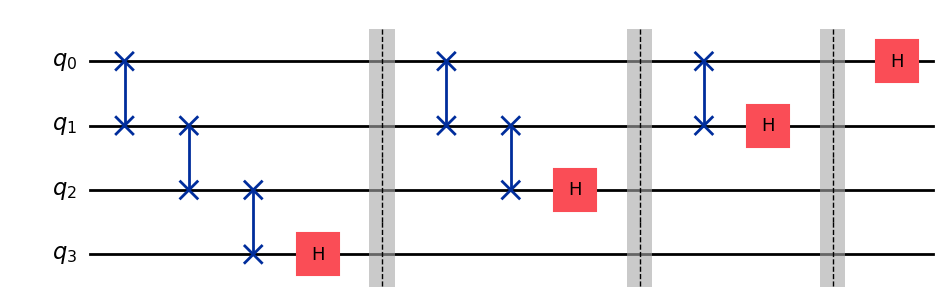

In [78]:
H = Operator.from_label("H")
I = Operator.from_label("I")
swap = np.array([[1, 0, 0, 0],
                 [0, 0, 1, 0],
                 [0, 1, 0, 0],
                 [0, 0, 0, 1]])
S = Operator(swap)

op1 = I^I^S
op2 = I^S^I
op3 = S^I^I
op = Operator(np.matmul(np.matmul(op3, op2), op1))

# latex_output = array_to_latex(
#     op.data, 
#     max_size=op.data.shape,
#     precision=3
# )
# display(latex_output)

qc = QuantumCircuit(4)
qc.swap(0, 1)
qc.swap(1, 2)
qc.swap(2, 3)
qc.h(3)
qc.barrier()
qc.swap(0, 1)
qc.swap(1, 2)
qc.h(2)
qc.barrier()
qc.swap(0, 1)
qc.h(1)
qc.barrier()
qc.h(0)

qc_op = Operator.from_circuit(qc)

latex_circuit = array_to_latex(
    qc_op.data, 
    max_size=qc_op.data.shape,
    precision=3
)
display(latex_circuit)
display(qc.draw(output="mpl"))